## Linear Regression
#### Find the relationships between the features and the rentals label.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# This ensures plots are displayed inline in the Jupyter notebook
%matplotlib inline

# load the training dataset
# !wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
bike_df = pd.read_csv('../../DATA/daily-bike-share.csv')
bike_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82



The data consists of the following columns:

- instant: A unique row identifier
- dteday: The date on which the data was observed - in this case, the data was collected daily; so there's one row per date.
- season: A numerically encoded value indicating the season (1:winter, 2:spring, 3:summer, 4:fall)
- yr: The year of the study in which the observation was made (the study took place over two years - year 0 represents 2011, and year 1 represents 2012)
- mnth: The calendar month in which the observation was made (1:January ... 12:December)
- holiday: A binary value indicating whether or not the observation was made on a public holiday)
- weekday: The day of the week on which the observation was made (0:Sunday ... 6:Saturday)
- workingday: A binary value indicating whether or not the day is a working day (not a weekend or holiday)
- weathersit: A categorical value indicating the weather situation (1:clear, 2:mist/cloud, 3:light rain/snow, 4:heavy rain/hail/snow/fog)
- temp: The temperature in celsius (normalized)
- atemp: The apparent ("feels-like") temperature in celsius (normalized)
- hum: The humidity level (normalized)
- windspeed: The windspeed (normalized)
- rentals: The number of bicycle rentals recorded.
In this dataset, rentals represents the label (the y value) our model must be trained to predict. The other columns are potential features (x values).

In [3]:
## Letś add one column named Day, with the day of the date.
bike_df["Day"] = pd.DatetimeIndex(bike_df["dteday"]).day
bike_df.head(1)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,Day
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1


## Exploratory Data Analysis - Statistically

In [4]:
## There seem to be no categorical value, however, they could be masked with an integer like in a "rank" or "weekday"
bike_df.dtypes.value_counts()

## Describe method
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
bike_df[numeric_features + ['rentals']].describe()

,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471
std,0.183051,0.162961,0.142429,0.077498,686.622488
min,0.059130,0.079070,0.000000,0.022392,2.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000
50%,0.498333,0.486733,0.626667,0.180975,713.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000


We can see a huge standard deviation in the rentals attribute, indicating a wide variance in rental amount per day.

So, let's explore the rentals attribute a bit further

/tmp/ipykernel_31263/3169051025.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


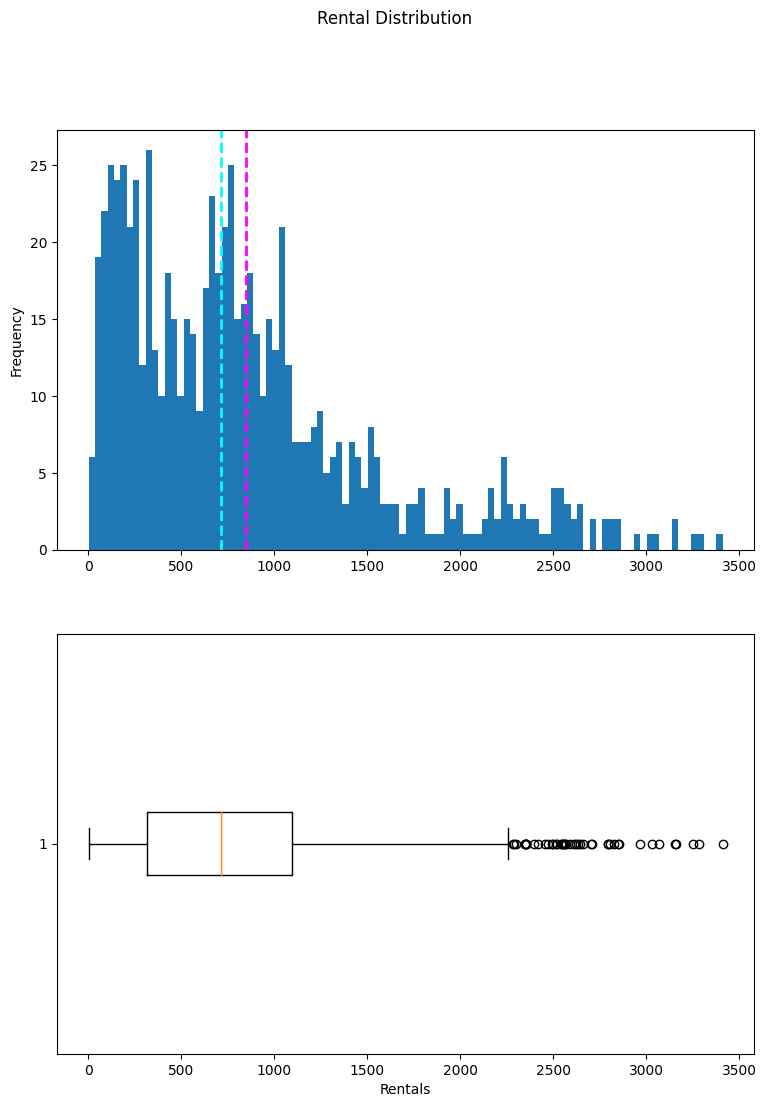

In [5]:
rentals = bike_df["rentals"]

# Create a figure for 2 subplots (2 rows, 1 column)
fig, ax = plt.subplots(2, 1, figsize = (9,12))

# Plot the histogram   
ax[0].hist(rentals, bins=100)
ax[0].set_ylabel('Frequency')

# Add lines for the mean, median, and mode
ax[0].axvline(rentals.mean(), color='magenta', linestyle='dashed', linewidth=2)
ax[0].axvline(rentals.median(), color='cyan', linestyle='dashed', linewidth=2)

# Plot the boxplot   
ax[1].boxplot(rentals, vert=False)
ax[1].set_xlabel('Rentals')

# Add a title to the Figure
fig.suptitle('Rental Distribution')

# Show the figure
fig.show()


The plots show that the number of daily rentals ranges from 0 to just over 3,400. However, the mean (and median) number of daily rentals is closer to the low end of that range, with most of the data between 0 and around 2,200 rentals. The few values above this are shown in the box plot as small circles, indicating that they are outliers - in other words, unusually high or low values beyond the typical range of most of the data.

## Let's check all numeric attributes distribution
##### - If mean > median, distribution is skewed to the right.
##### - If mean < median, distribution is skewed to the left.

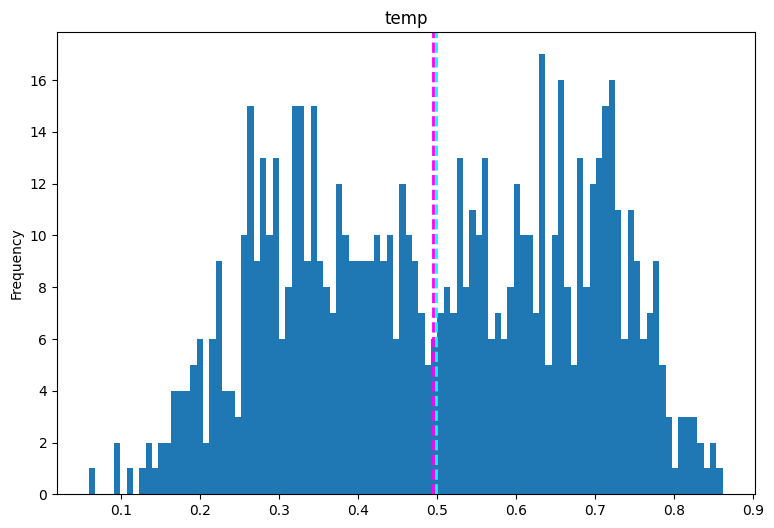

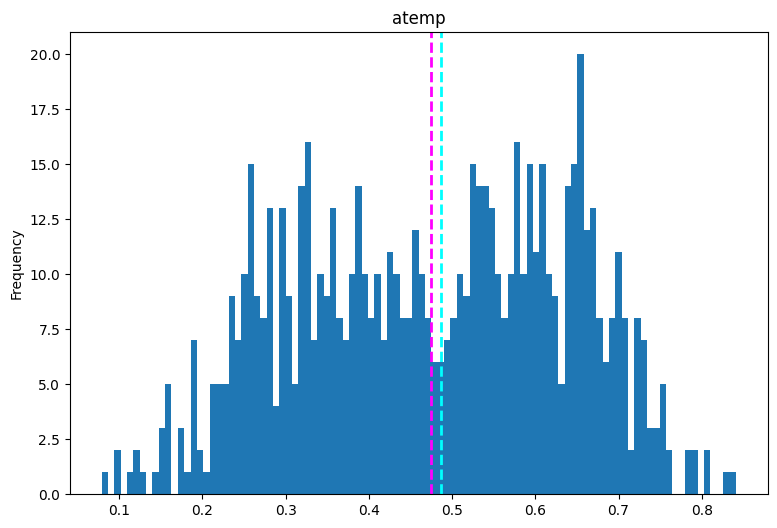

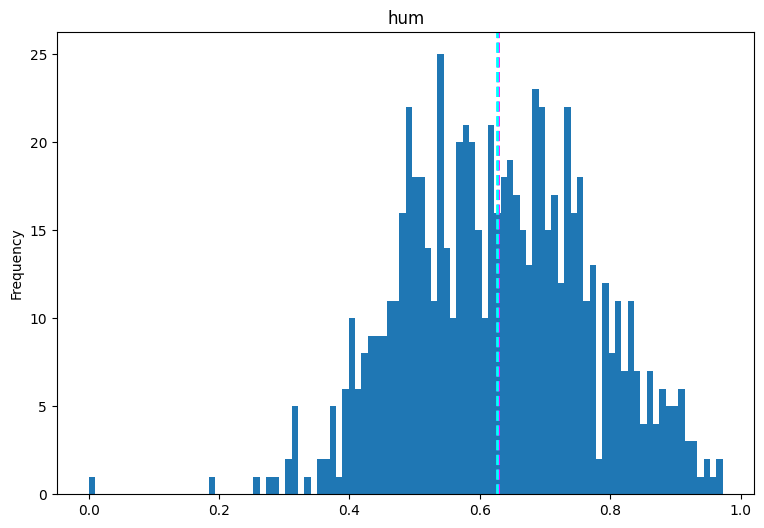

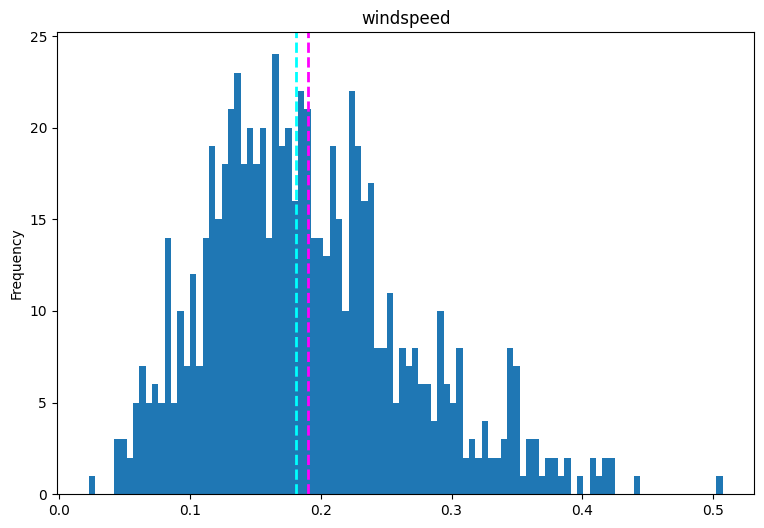

In [6]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    attribute = bike_df[col]
    attribute.plot.hist(bins=100, ax = ax)
    ax.axvline(attribute.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(attribute.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

## Let's check all categorical attributes distributions

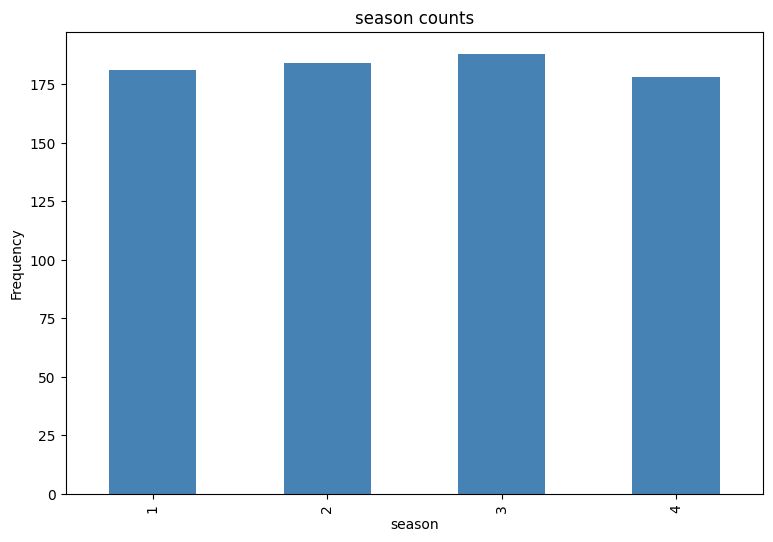

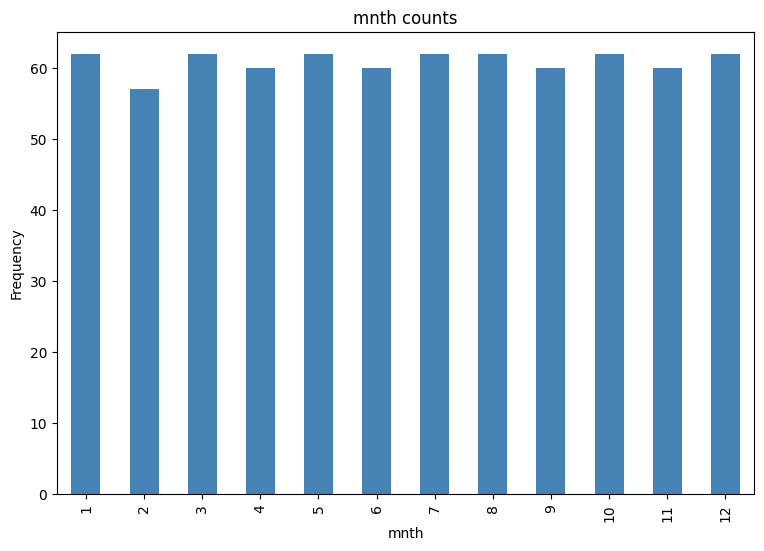

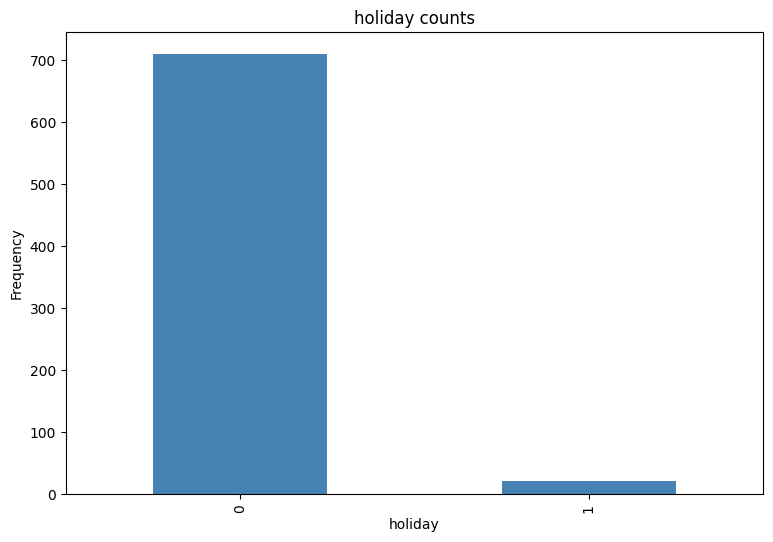

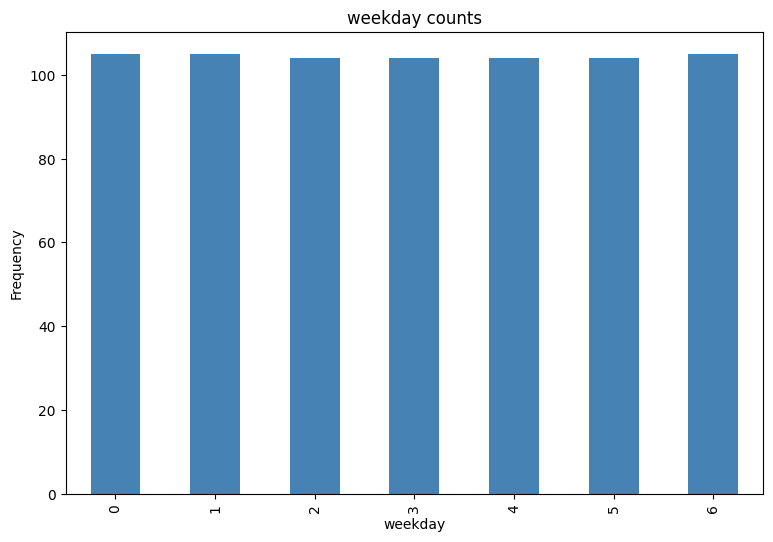

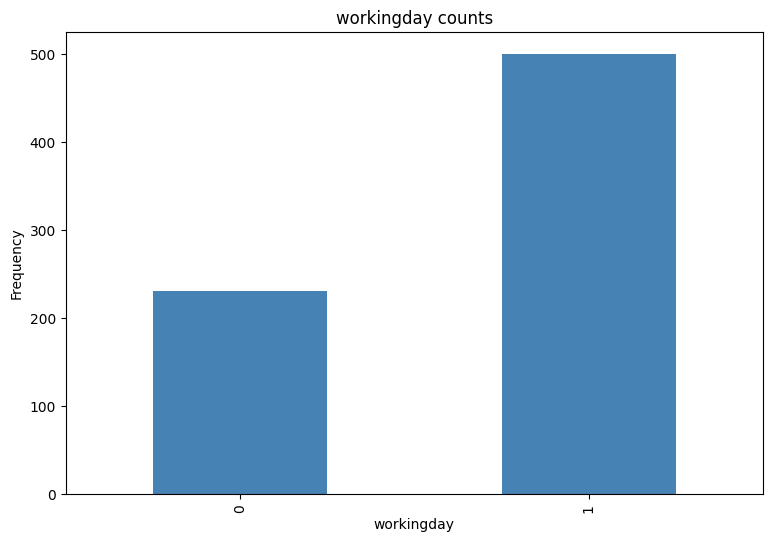

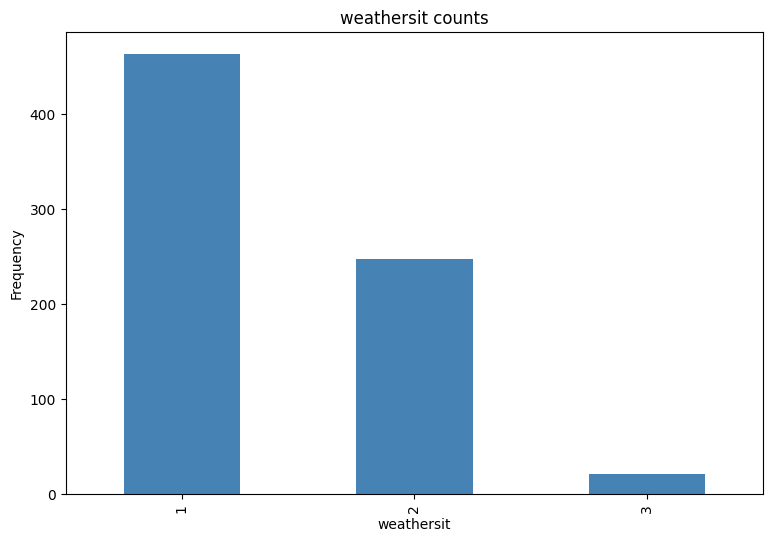

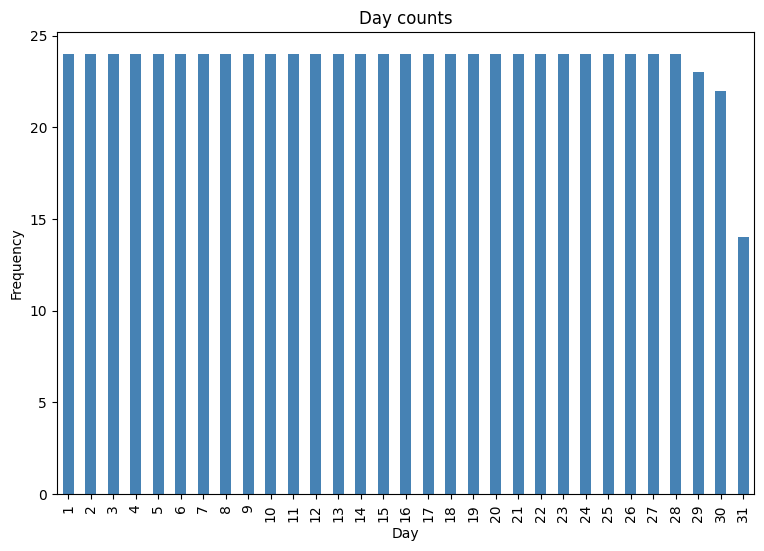

In [7]:
# plot a bar plot for each categorical feature count
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'Day']

for col in categorical_features:
    counts = bike_df[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col) 
    ax.set_ylabel("Frequency")
plt.show()


### We can also check the correlation of each numerical attribute against the rentals.

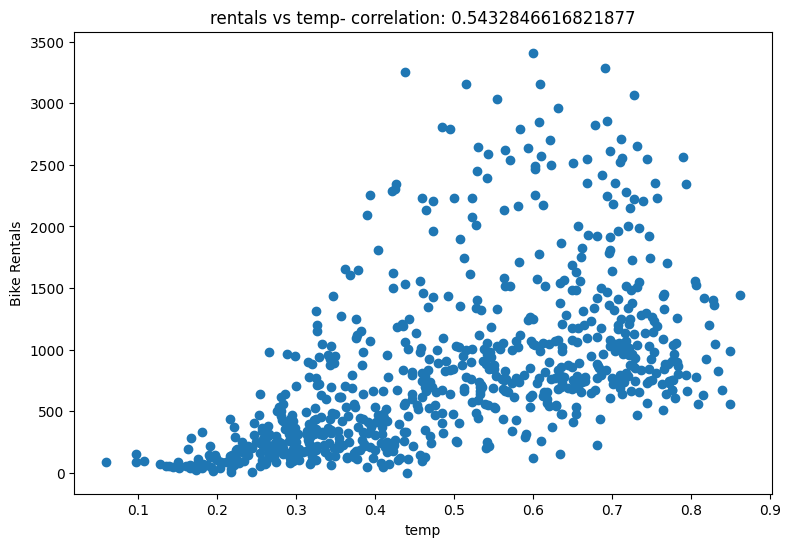

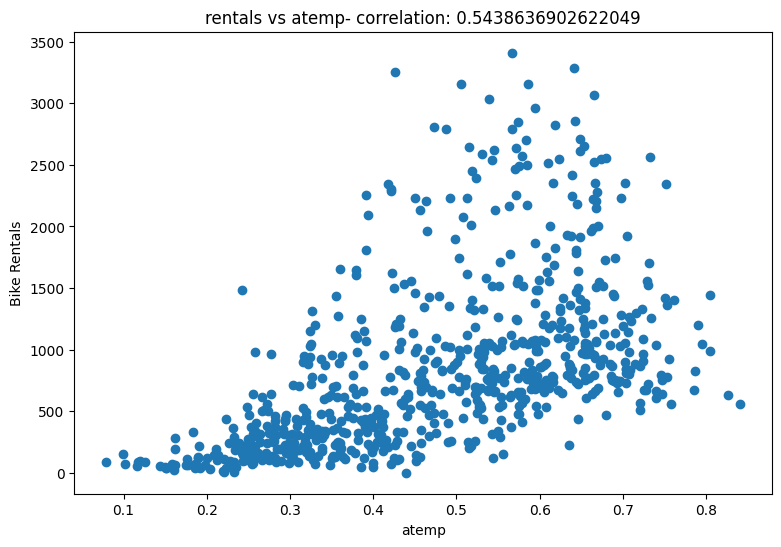

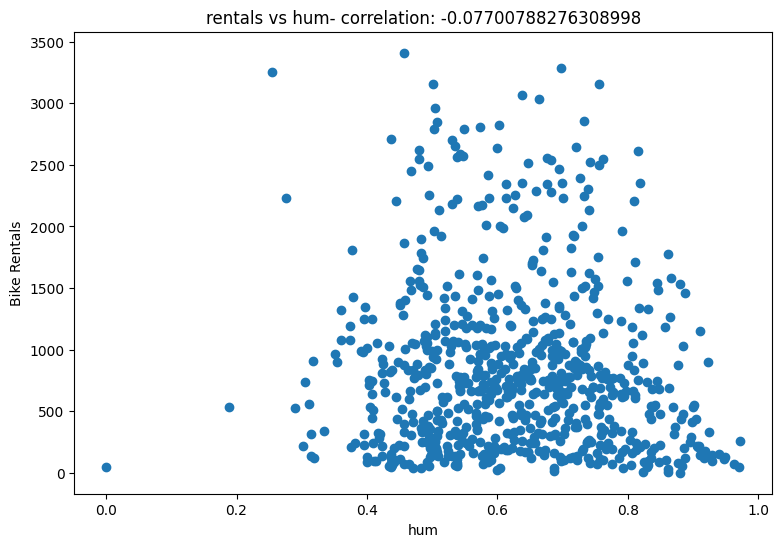

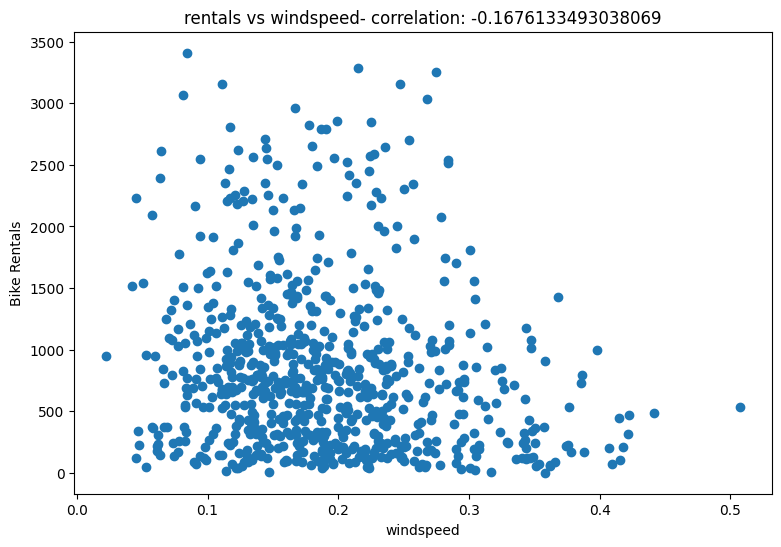

In [8]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = bike_df[col]
    label = bike_df['rentals']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Bike Rentals')
    ax.set_title('rentals vs ' + col + '- correlation: ' + str(correlation))
plt.show()

### Now the categorical attributes against the rentals

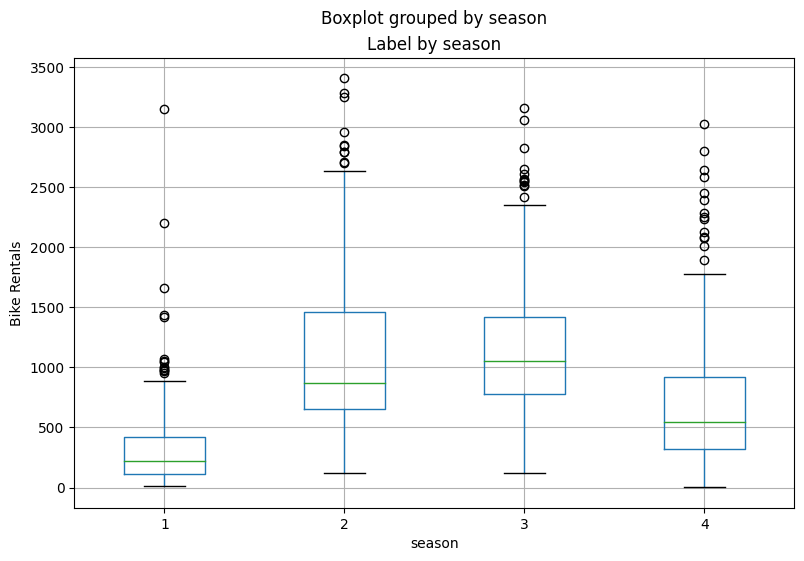

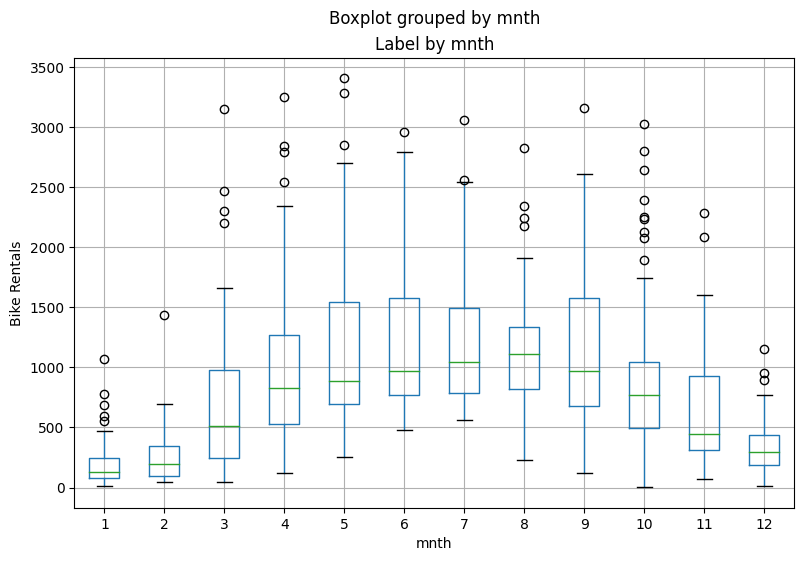

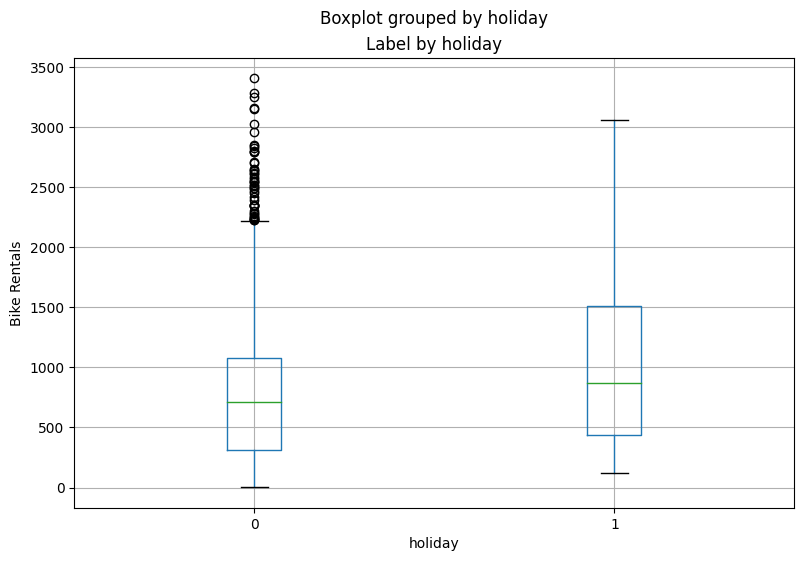

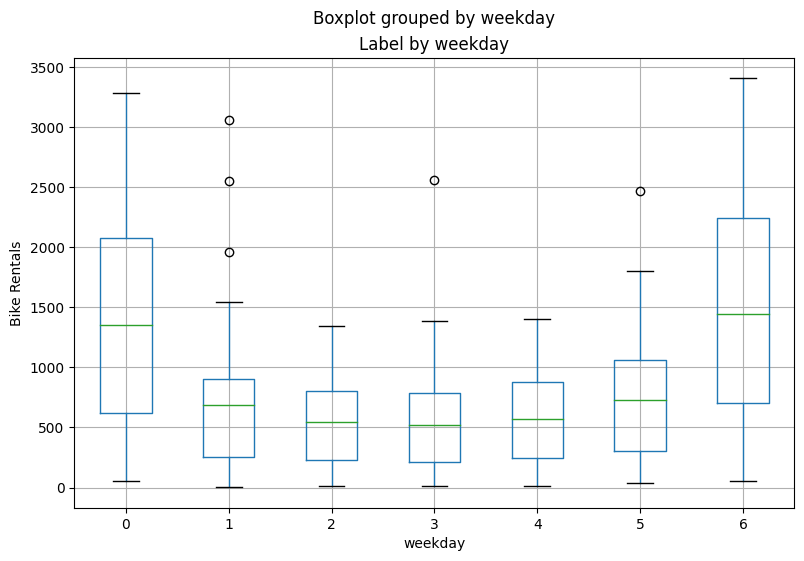

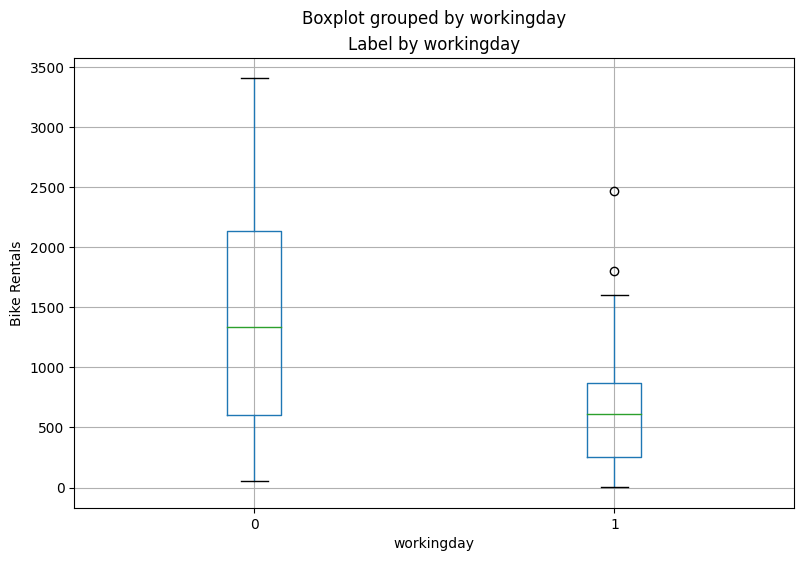

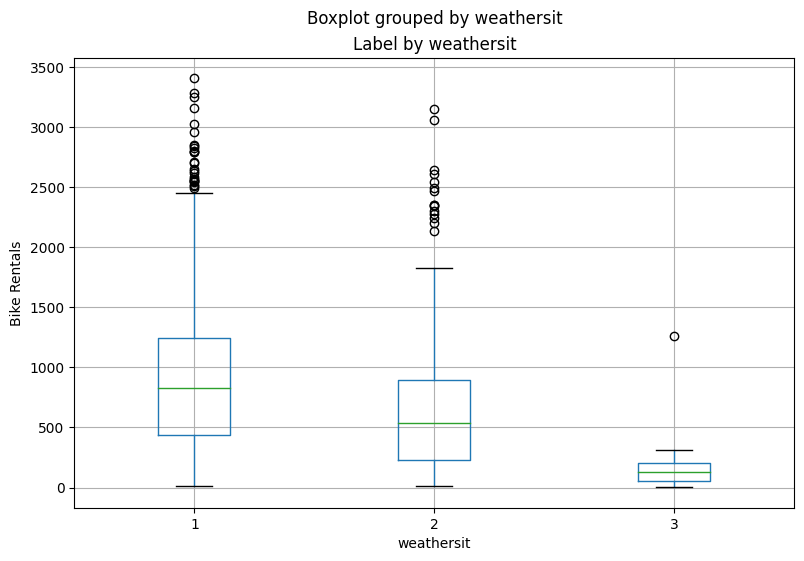

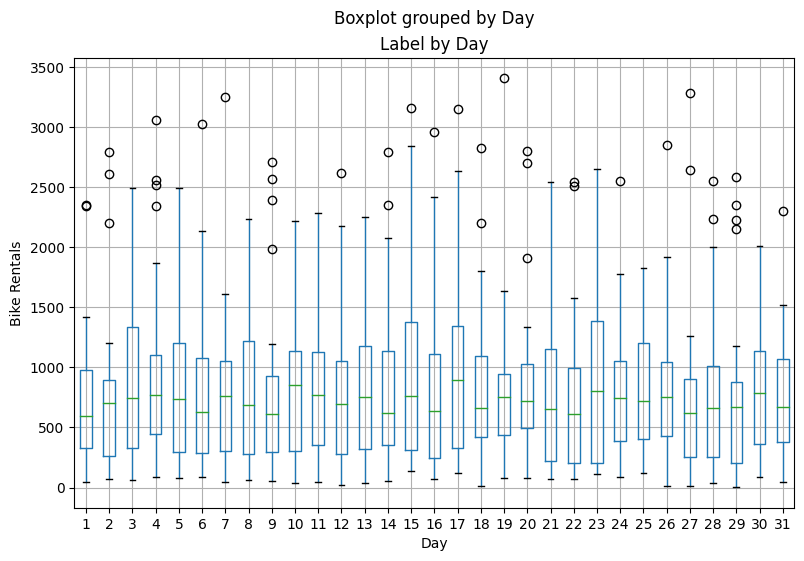

In [9]:
# plot a boxplot for the label by each categorical feature
for col in categorical_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    bike_df.boxplot(column = 'rentals', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("Bike Rentals")
plt.show()

## Train a Regression Model

### 1. Prepare the tranining and test data sets

In [10]:
# Separate features and labels
# into numpy arrays named X containing the features, and y containing the labels
X, y = bike_df[['season','mnth', 'holiday','weekday','workingday','weathersit','temp', 'atemp', 'hum', 'windspeed']].values, bike_df['rentals'].values
print('Features:',X[:10], '\nLabels:', y[:10], sep='\n')

Features:
[[1.        1.        0.        6.        0.        2.        0.344167
  0.363625  0.805833  0.160446 ]
 [1.        1.        0.        0.        0.        2.        0.363478
  0.353739  0.696087  0.248539 ]
 [1.        1.        0.        1.        1.        1.        0.196364
  0.189405  0.437273  0.248309 ]
 [1.        1.        0.        2.        1.        1.        0.2
  0.212122  0.590435  0.160296 ]
 [1.        1.        0.        3.        1.        1.        0.226957
  0.22927   0.436957  0.1869   ]
 [1.        1.        0.        4.        1.        1.        0.204348
  0.233209  0.518261  0.0895652]
 [1.        1.        0.        5.        1.        2.        0.196522
  0.208839  0.498696  0.168726 ]
 [1.        1.        0.        6.        0.        2.        0.165
  0.162254  0.535833  0.266804 ]
 [1.        1.        0.        0.        0.        1.        0.138333
  0.116175  0.434167  0.36195  ]
 [1.        1.        0.        1.        1.        1.        

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)
print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))

Training Set: 511 rows
Test Set: 220 rows


### 2. Model - Linear vs Ridge Regression

In [16]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression().fit(X_train, y_train)
print (linear_regression_model)

predictions = linear_regression_model.predict(X_test)
np.set_printoptions(suppress=True)
print('Predicted labels: ', np.round(predictions)[:10])
print('Actual labels   : ' ,y_test[:10])

from sklearn.linear_model import Ridge as RidgeRegression

ridge_regression_model = RidgeRegression().fit(X_train, y_train)
print (ridge_regression_model)

predictions_ridge = ridge_regression_model.predict(X_test)
np.set_printoptions(suppress=True)
print('Predicted labels: ', np.round(predictions_ridge)[:10])
print('Actual labels   : ' ,y_test[:10])

LinearRegression()
Predicted labels:  [1896. 1184. 1007.  -28.  314.  385.  475.  590. 1476.  -22.]
Actual labels   :  [2418  754  222   47  244  145  240  555 3252   38]
Ridge()
Predicted labels:  [1883. 1166.  964.  -24.  297.  384.  505.  610. 1460.  -13.]
Actual labels   :  [2418  754  222   47  244  145  240  555 3252   38]


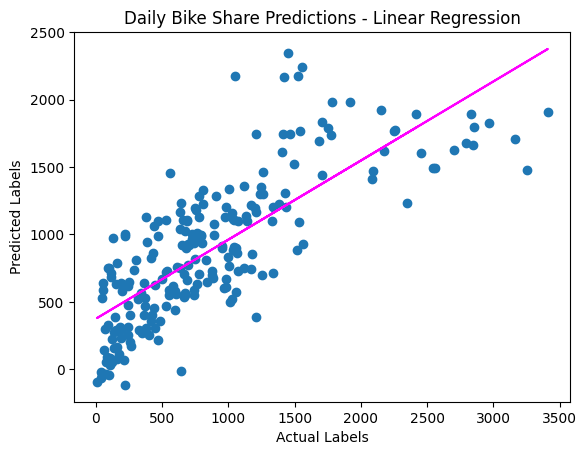

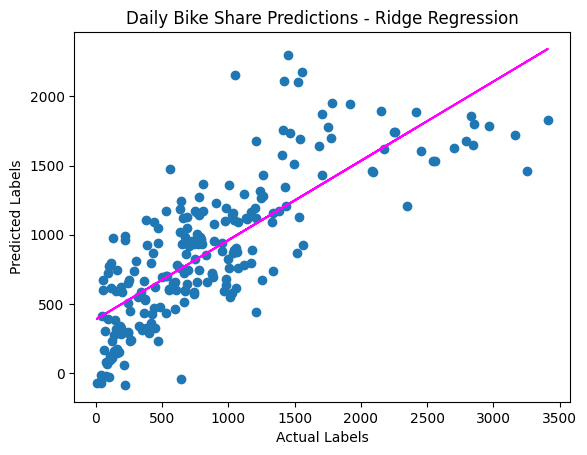

In [19]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions - Linear Regression')
# highlight the regression line
z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()

plt.scatter(y_test, predictions_ridge)
plt.xlabel('Actual Labels')
plt.ylabel('Predicted Labels')
plt.title('Daily Bike Share Predictions - Ridge Regression')
# highlight the regression line
z = np.polyfit(y_test, predictions_ridge, 1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test), color='magenta')
plt.show()


##### There's a definite diagonal trend, and the intersections of the predicted and actual values are generally following the path of the trend line;
##### but there's a fair amount of difference between the ideal function represented by the line and the results.
##### This variance represents the residuals of the model.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression Error Metrics:")
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, predictions)
print("R2:", r2)

print("\nRidge Regression Error Metrics:")
mse_ridge = mean_squared_error(y_test, predictions_ridge)
print("MSE:", mse_ridge)

rmse_ridge = np.sqrt(mse_ridge)
print("RMSE:", rmse_ridge)

r2_ridge = r2_score(y_test, predictions_ridge)
print("R2:", r2_ridge)

Linear Regression Error Metrics:
MSE: 201972.55947035595
RMSE: 449.4135728595165
R2: 0.604045473691919

Ridge Regression Error Metrics:
MSE: 198661.3520517049
RMSE: 445.7144288125581
R2: 0.6105368880127452
